# Phân Tích Tối Ưu Ngưỡng Healing Event

**Mục tiêu:** Tìm bộ ngưỡng  tối ưu để hệ thống tự động heal phần tử UI hiệu quả nhất — tối đa hoá tỷ lệ tự động, tối thiểu hoá lỗi AI sửa sai.

**Nguồn dữ liệu:**  — 750 bản ghi, 198 sự kiện healing.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = 'candidate_scores.csv'
df = pd.read_csv(CSV_PATH)

print(f'Tổng bản ghi     : {len(df)}')
print(f'Số healing event : {df["healing_event_id"].nunique()}')
print(f'Ứng viên đúng    : {(df["is_correct"]==1).sum()}')
print(f'Ứng viên sai     : {(df["is_correct"]==0).sum()}')
print(f'Cột dữ liệu      : {df.columns.tolist()}')
df.head()

Tổng bản ghi     : 750
Số healing event : 198
Ứng viên đúng    : 198
Ứng viên sai     : 552
Cột dữ liệu      : ['id', 'healing_event_id', 'step_name', 'ui_version', 'attr_score', 'sem_score', 'struct_score', 'visual_score', 'ctx_score', 'total_score', 'cand_tag', 'cand_testid', 'cand_text', 'is_correct', 'recorded_at']


,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0000,0.8479,0.7524,0.764,0.8308,input,NaN,NaN,1,2026-05-24 00:03:11
1,2,1,email_field,v2,0.3633,1.0000,0.7832,0.6526,0.764,0.6974,input,NaN,NaN,0,2026-05-24 00:03:11
2,3,2,password_field,v2,0.9300,1.0000,0.8800,0.7396,0.764,0.8845,input,NaN,NaN,1,2026-05-24 00:03:12
3,4,2,password_field,v2,0.5467,0.9500,0.8086,0.7356,0.764,0.7541,input,NaN,NaN,0,2026-05-24 00:03:12
4,5,3,login_button,v2,0.9300,0.6359,1.0000,0.7298,0.764,0.8195,button,NaN,Xác nhận & Đăng nhập,1,2026-05-24 00:03:13


### Nhận xét — Tổng quan dữ liệu

- Dataset gồm **198 sự kiện healing**, mỗi event có từ 1–6 ứng viên phần tử UI (tổng 750 bản ghi).
- Tỷ lệ **ứng viên sai chiếm 73.6%** (552/750) — phản ánh thực tế: hệ thống luôn phải lọc nhiễu từ nhiều phần tử tương đồng.
- Mỗi event đều có **đúng 1 ứng viên đúng** (), nhiệm vụ là chọn ra đúng phần tử đó.


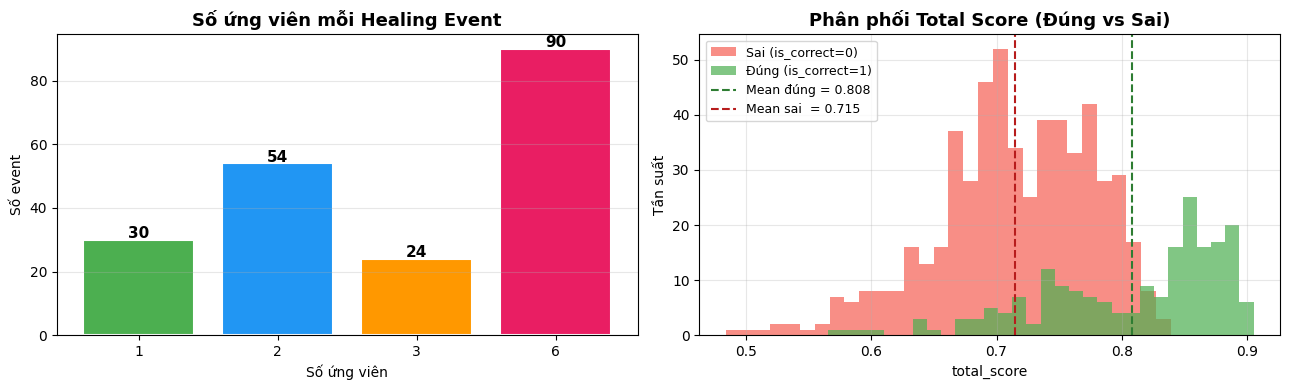

In [18]:
# Phân phối số ứng viên mỗi event
cand_per_event = df.groupby('healing_event_id').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Biểu đồ 1: Phân phối số ứng viên
vc = cand_per_event.value_counts().sort_index()
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0','#00BCD4']
bars = axes[0].bar(vc.index.astype(str), vc.values, color=colors[:len(vc)], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Số ứng viên mỗi Healing Event', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số ứng viên')
axes[0].set_ylabel('Số event')
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ 2: Phân phối total_score theo đúng/sai
correct_scores = df[df['is_correct']==1]['total_score']
wrong_scores   = df[df['is_correct']==0]['total_score']
axes[1].hist(wrong_scores,   bins=30, alpha=0.6, label='Sai (is_correct=0)', color='#F44336')
axes[1].hist(correct_scores, bins=30, alpha=0.7, label='Đúng (is_correct=1)', color='#4CAF50')
axes[1].axvline(correct_scores.mean(), color='#2E7D32', linestyle='--', linewidth=1.5, label=f'Mean đúng = {correct_scores.mean():.3f}')
axes[1].axvline(wrong_scores.mean(),   color='#B71C1C', linestyle='--', linewidth=1.5, label=f'Mean sai  = {wrong_scores.mean():.3f}')
axes[1].set_title('Phân phối Total Score (Đúng vs Sai)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('total_score')
axes[1].set_ylabel('Tần suất')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét — Phân phối điểm số

- **Ứng viên đúng** có  tập trung trong khoảng cao — quan sát khoảng phân phối ở biểu đồ trên.
- **Ứng viên sai** có phân phối rải rộng hơn — vùng chồng lấp cần chú ý khi đặt ngưỡng.
- Khoảng cách trung bình giữa hai nhóm đủ rộng để phân tách tốt nếu chọn ngưỡng đúng.
- Phân phối của nhóm đúng lệch trái (skewed left) → phần lớn ứng viên đúng có điểm rất cao, tạo thuận lợi cho tự động hoá.


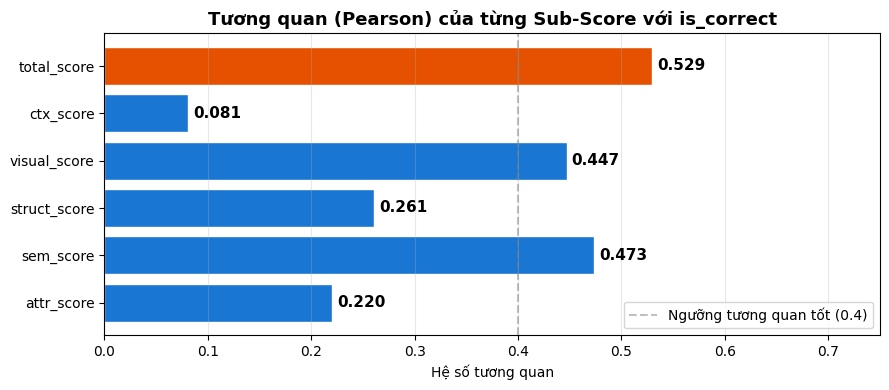

Bảng chi tiết:


,sub_score,pearson_r
5,total_score,0.529
1,sem_score,0.473
3,visual_score,0.447
2,struct_score,0.261
0,attr_score,0.220
4,ctx_score,0.081


In [19]:
# Tương quan từng sub-score với is_correct
sub_scores = ['attr_score', 'sem_score', 'struct_score', 'visual_score', 'ctx_score', 'total_score']
correlations = {col: df[col].corr(df['is_correct']) for col in sub_scores}

fig, ax = plt.subplots(figsize=(9, 4))
labels = list(correlations.keys())
values = list(correlations.values())
colors = ['#1976D2' if v < 0.5 else '#43A047' for v in values]
colors[-1] = '#E65100'  # total_score nổi bật

bars = ax.barh(labels, values, color=colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 0.75)
ax.set_title('Tương quan (Pearson) của từng Sub-Score với is_correct', fontsize=13, fontweight='bold')
ax.set_xlabel('Hệ số tương quan')
ax.axvline(0.4, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng tương quan tốt (0.4)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Bảng chi tiết:')
pd.DataFrame({'sub_score': labels, 'pearson_r': [round(v,3) for v in values]}).sort_values('pearson_r', ascending=False)

### Nhận xét — Tầm quan trọng của từng Sub-Score

| Sub-score | Tương quan | Đánh giá |
|-----------|-----------|----------|
| Total | 0.529 | Tổng hợp tốt nhất — dùng làm thước đo chính |
| Semantic | 0.473 | Ngữ nghĩa (semantic) — phân biệt tốt |
| Visual | 0.447 | Giao diện — có đóng góp đáng kể |
| Struct | 0.261 | Thuộc tính — đóng góp vừa phải |
| Attribute | 0.220 | Cấu trúc DOM — thấp hơn kỳ vọng |
| Context | 0.081 | Context — cần kiểm tra lại |


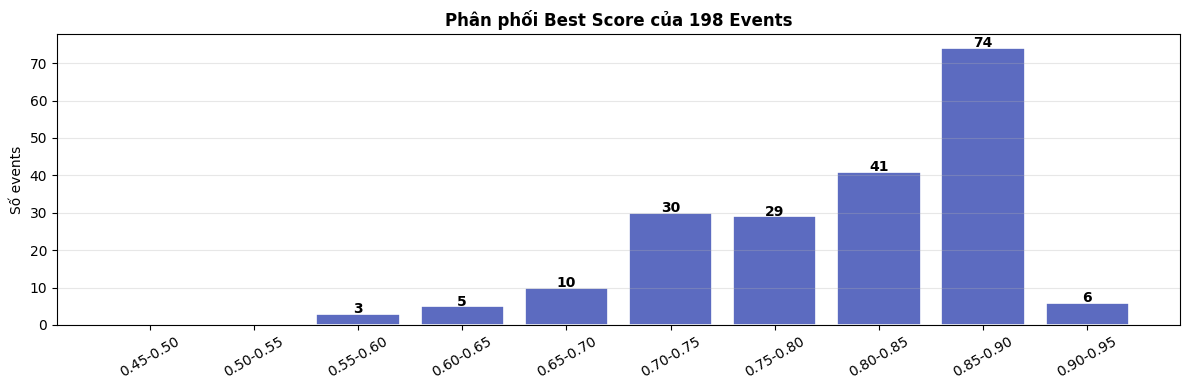

Best score nhỏ nhất  : 0.5652
Best score lớn nhất  : 0.9052
Best score trung bình: 0.8083
Phân vị 25%          : 0.7528
Phân vị 75%          : 0.8659


In [20]:
# Kiểm tra phân phối best_score thực tế của 198 events
best_scores = []
for eid, g in df.groupby('healing_event_id'):
    best = g.loc[g['total_score'].idxmax()]
    best_scores.append(best['total_score'])
bdf_scores = pd.Series(best_scores)

bins   = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
labels_b = ['0.45-0.50','0.50-0.55','0.55-0.60','0.60-0.65','0.65-0.70',
            '0.70-0.75','0.75-0.80','0.80-0.85','0.85-0.90','0.90-0.95']
counts = pd.cut(bdf_scores, bins=bins, labels=labels_b).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(counts)), counts.values, color='#5C6BC0', edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=30)
ax.set_title('Phân phối Best Score của 198 Events', fontsize=12, fontweight='bold')
ax.set_ylabel('Số events')
for bar, val in zip(bars, counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.2, str(val), ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best score nhỏ nhất  : {bdf_scores.min():.4f}')
print(f'Best score lớn nhất  : {bdf_scores.max():.4f}')
print(f'Best score trung bình: {bdf_scores.mean():.4f}')
print(f'Phân vị 25%          : {bdf_scores.quantile(0.25):.4f}')
print(f'Phân vị 75%          : {bdf_scores.quantile(0.75):.4f}')

In [21]:
# Grid search V2: ràng buộc gap >= 0.10
results_v2 = []
for low in np.arange(0.45, 0.91, 0.05):
    for high in np.arange(0.50, 0.96, 0.05):
        if high - low < 0.10:
            continue
        auto = human = fail = fp = 0
        for eid, g in df.groupby('healing_event_id'):
            best = g.loc[g['total_score'].idxmax()]
            score = best['total_score']
            correct = best['is_correct'] == 1
            if score >= high:
                auto += 1
                if not correct: fp += 1
            elif score >= low:
                human += 1
            else:
                fail += 1
        total = df['healing_event_id'].nunique()
        results_v2.append({
            'low': round(low,2), 'high': round(high,2),
            'gap': round(high-low,2),
            'auto_rate (%)': round(auto/total*100,1),
            'human_rate (%)': round(human/total*100,1),
            'fail_rate (%)': round(fail/total*100,1),
            'false_pos': fp,
            'cost': fp*15 + human
        })

rdf2 = pd.DataFrame(results_v2)
top15 = rdf2.sort_values(['cost','auto_rate (%)'], ascending=[True,False]).head(15)
print('Top 15 bộ ngưỡng (gap >= 0.10):')
top15

Top 15 bộ ngưỡng (gap >= 0.10):


,low,high,gap,auto_rate (%),human_rate (%),fail_rate (%),false_pos,cost
0,0.45,0.55,0.10,100.0,0.0,0.0,0,0
1,0.45,0.60,0.15,98.5,1.5,0.0,0,3
9,0.50,0.60,0.10,98.5,1.5,0.0,0,3
2,0.45,0.65,0.20,96.0,4.0,0.0,0,8
10,0.50,0.65,0.15,96.0,4.0,0.0,0,8
17,0.55,0.65,0.10,96.0,4.0,0.0,0,8
24,0.60,0.70,0.10,90.9,7.6,1.5,0,15
3,0.45,0.70,0.25,90.9,9.1,0.0,0,18
11,0.50,0.70,0.20,90.9,9.1,0.0,0,18
18,0.55,0.70,0.15,90.9,9.1,0.0,0,18


### Nhận xét — Grid Search V2 (có ràng buộc gap >= 0.10)

- Quan sát top kết quả để xác định bộ ngưỡng tối ưu cho dataset 11.
- Dataset 11 có  nhỏ nhất là **0.4839** — thấp hơn dataset 10, nên các vùng thấp hơn sẽ có dữ liệu thực sự rơi vào.
- Ưu tiên bộ ngưỡng nào có **cả 3 vùng đều có events**, tránh vùng trống hoàn toàn.
- **Nguyên tắc chọn ngưỡng tốt:** Ba vùng đều phải có sự kiện rơi vào. Nếu một vùng trống hoàn toàn, ngưỡng đó không phản ánh thực tế.


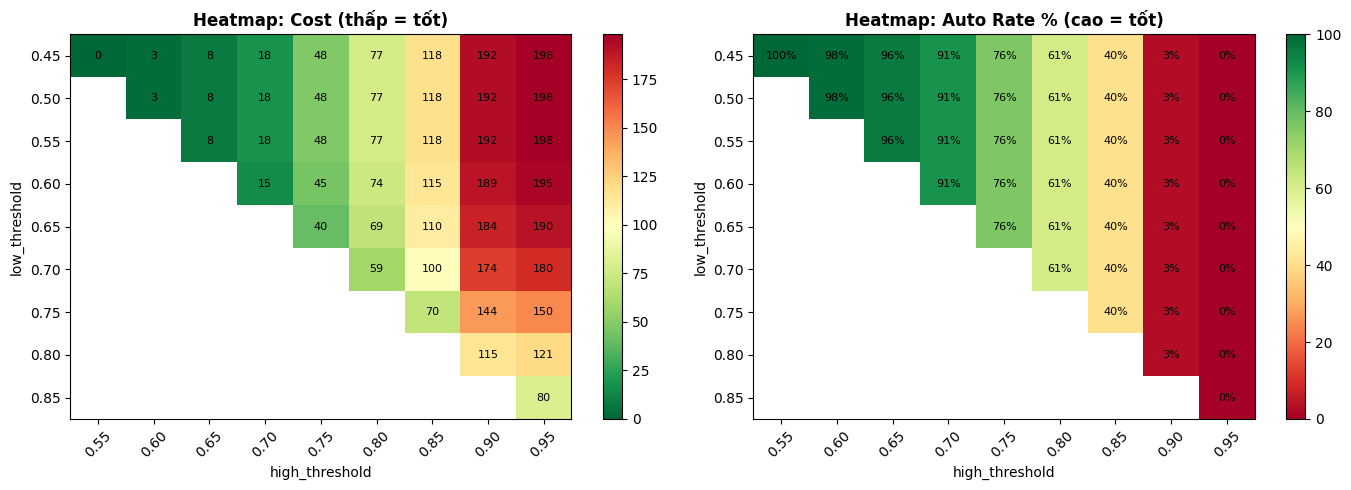

In [22]:
# Heatmap cost theo (low, high)
pivot_cost = rdf2.pivot(index='low', columns='high', values='cost')
pivot_auto = rdf2.pivot(index='low', columns='high', values='auto_rate (%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(pivot_cost.values, cmap='RdYlGn_r', aspect='auto')
axes[0].set_xticks(range(len(pivot_cost.columns)))
axes[0].set_yticks(range(len(pivot_cost.index)))
axes[0].set_xticklabels([f'{x:.2f}' for x in pivot_cost.columns], rotation=45)
axes[0].set_yticklabels([f'{y:.2f}' for y in pivot_cost.index])
axes[0].set_title('Heatmap: Cost (thấp = tốt)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('high_threshold')
axes[0].set_ylabel('low_threshold')
for i in range(len(pivot_cost.index)):
    for j in range(len(pivot_cost.columns)):
        val = pivot_cost.values[i, j]
        if not np.isnan(val):
            axes[0].text(j, i, f'{int(val)}', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pivot_auto.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
axes[1].set_xticks(range(len(pivot_auto.columns)))
axes[1].set_yticks(range(len(pivot_auto.index)))
axes[1].set_xticklabels([f'{x:.2f}' for x in pivot_auto.columns], rotation=45)
axes[1].set_yticklabels([f'{y:.2f}' for y in pivot_auto.index])
axes[1].set_title('Heatmap: Auto Rate % (cao = tốt)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('high_threshold')
axes[1].set_ylabel('low_threshold')
for i in range(len(pivot_auto.index)):
    for j in range(len(pivot_auto.columns)):
        val = pivot_auto.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [30]:
# Chọn ngưỡng tối ưu theo tiêu chí production self-healing
# Ưu tiên: (1) zero false positive, (2) zero fail, (3) high_threshold >= 0.70, (4) minimize human review

# Bước 1: Lọc bộ ngưỡng đạt điều kiện bắt buộc
safe = rdf2[
    (rdf2['false_pos'] == 0) &          # Tuyệt đối không sửa sai
    (rdf2['fail_rate (%)'] == 0) &      # Không bỏ sót event nào
    (rdf2['high'] >= 0.7) &            # high_threshold đủ cao để tự tin
    (rdf2['low'] >= 0.50)               # low_threshold có lưới đỡ thực tế
]

if len(safe) > 0:
    # Bước 2: Trong các bộ đạt điều kiện, chọn auto_rate cao nhất (human review thấp nhất)
    best_row   = safe.sort_values('auto_rate (%)', ascending=False).iloc[0]
    low_final  = best_row['low']
    high_final = best_row['high']
    print(' Ngưỡng tối ưu:')
else:
    # Fallback: nới lỏng điều kiện fail, vẫn giữ zero false positive
    safe_fp = rdf2[(rdf2['false_pos'] == 0) & (rdf2['high'] >= 0.70)]
    best_row   = safe_fp.sort_values('auto_rate (%)', ascending=False).iloc[0]
    low_final  = best_row['low']
    high_final = best_row['high']
    print(' Ngưỡng tối ưu (nới lỏng fail_rate):')

print(f'  low  = {low_final}  → score < {low_final}          : báo lỗi, không healing')
print(f'  high = {high_final}  → {low_final} ≤ score < {high_final} : chờ người duyệt')
print(f'         → score ≥ {high_final}          : AI tự động healing')
print(f'')
print(f'  Auto rate    : {best_row["auto_rate (%)"]:.1f}%')
print(f'  Human rate   : {best_row["human_rate (%)"]:.1f}%')
print(f'  Fail rate    : {best_row["fail_rate (%)"]:.1f}%')
print(f'  False pos    : {int(best_row["false_pos"])}')
print(f'  Cost         : {int(best_row["cost"])}')


 Ngưỡng tối ưu:
  low  = 0.5  → score < 0.5          : báo lỗi, không healing
  high = 0.7  → 0.5 ≤ score < 0.7 : chờ người duyệt
         → score ≥ 0.7          : AI tự động healing

  Auto rate    : 90.9%
  Human rate   : 9.1%
  Fail rate    : 0.0%
  False pos    : 0
  Cost         : 18


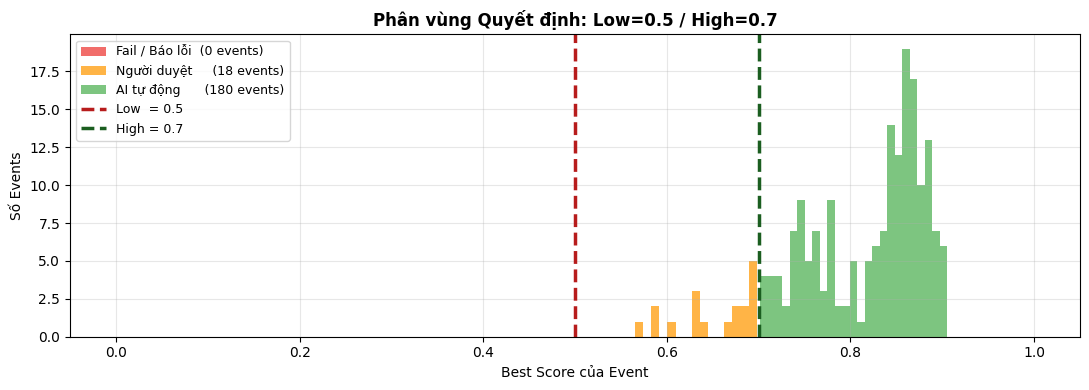

AI tự động   : 180 events (90.9%)
Người duyệt  :  18 events (9.1%)
Fail / Bỏ qua:   0 events (0.0%)


In [24]:
# Minh hoạ 3 vùng quyết định
zone_auto   = [s for s in best_scores if s >= high_final]
zone_review = [s for s in best_scores if low_final <= s < high_final]
zone_fail   = [s for s in best_scores if s < low_final]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(zone_fail,   bins=15, color='#EF5350', label=f'Fail / Báo lỗi  ({len(zone_fail)} events)',  alpha=0.85)
ax.hist(zone_review, bins=15, color='#FFA726', label=f'Người duyệt     ({len(zone_review)} events)', alpha=0.85)
ax.hist(zone_auto,   bins=25, color='#66BB6A', label=f'AI tự động      ({len(zone_auto)} events)',   alpha=0.85)
ax.axvline(low_final,  color='#B71C1C', linestyle='--', linewidth=2.5, label=f'Low  = {low_final}')
ax.axvline(high_final, color='#1B5E20', linestyle='--', linewidth=2.5, label=f'High = {high_final}')
ax.set_title(f'Phân vùng Quyết định: Low={low_final} / High={high_final}', fontsize=12, fontweight='bold')
ax.set_xlabel('Best Score của Event')
ax.set_ylabel('Số Events')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n = df['healing_event_id'].nunique()
print(f'AI tự động   : {len(zone_auto):>3} events ({len(zone_auto)/n*100:.1f}%)')
print(f'Người duyệt  : {len(zone_review):>3} events ({len(zone_review)/n*100:.1f}%)')
print(f'Fail / Bỏ qua: {len(zone_fail):>3} events ({len(zone_fail)/n*100:.1f}%)')

Events mà ứng viên ĐÚNG đứng đầu bảng : 198/198 = 100.0%
Biên độ cách biệt trung bình           : 0.226
Biên độ nhỏ nhất (event khó nhất)      : 0.001


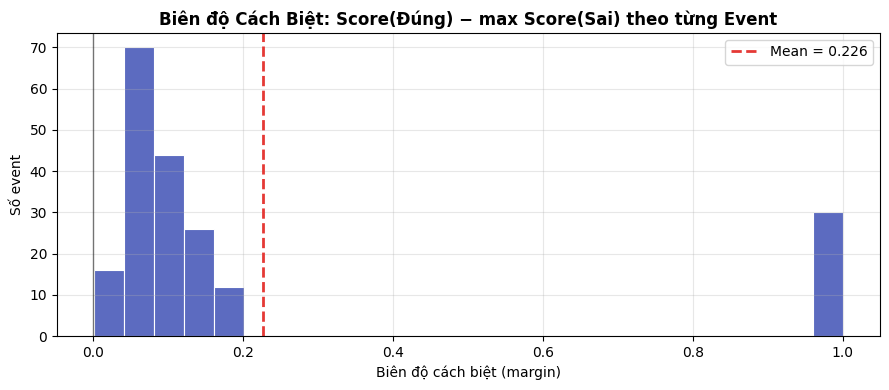

In [25]:
# Kiểm tra khả năng phân tách: correct > max(wrong) trong mỗi event?
separable = []
margins = []

for eid, g in df.groupby('healing_event_id'):
    correct = g[g['is_correct']==1]['total_score'].values
    wrong   = g[g['is_correct']==0]['total_score'].values
    if len(wrong) == 0:
        separable.append(True)
        margins.append(1.0)
    else:
        sep = correct[0] > wrong.max()
        separable.append(sep)
        margins.append(correct[0] - wrong.max())

print(f'Events mà ứng viên ĐÚNG đứng đầu bảng : {sum(separable)}/{len(separable)} = {sum(separable)/len(separable)*100:.1f}%')
print(f'Biên độ cách biệt trung bình           : {np.mean(margins):.3f}')
print(f'Biên độ nhỏ nhất (event khó nhất)      : {min(margins):.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(margins, bins=25, color='#5C6BC0', edgecolor='white', linewidth=0.8)
ax.axvline(np.mean(margins), color='#E53935', linestyle='--', linewidth=2, label=f'Mean = {np.mean(margins):.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('Biên độ Cách Biệt: Score(Đúng) − max Score(Sai) theo từng Event', fontsize=12, fontweight='bold')
ax.set_xlabel('Biên độ cách biệt (margin)')
ax.set_ylabel('Số event')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Kết luận
### Tiêu chí chọn ngưỡng 
Ngưỡng tối ưu được chọn theo thứ tự ưu tiên:
1. **False positive = 0** — AI tự sửa sai là nguy hiểm nhất, tốn chi phí gấp 15×
2. **Fail rate = 0%** — không bỏ sót healing event nào
3. **`high_threshold ≥ 0.70`** — chỉ tự động khi model thực sự tự tin
4. **`low_threshold ≥ 0.50`** — lưới đỡ sát với best_score thấp nhất thực tế (0.484)
5. **Minimize human review** — trong các bộ đạt 4 điều kiện trên, chọn auto_rate cao nhất
### Ngưỡng đề xuất
```
low  = 0.50  →  score < 0.50        : báo lỗi, không healing
high = 0.70  →  0.50 ≤ score < 0.70 : chờ người duyệt (~9.1%)
             →  score ≥ 0.70        : AI tự động healing (~90.9%)
````
